# Titanic 생존 예측 - Feature Engineering Pipeline

## 과제 목표
실제 데이터를 활용하여 머신러닝 성능 향상을 위한 특성 공학(Feature Engineering) 파이프라인을 설계하고,
전처리 및 변수 선택 전략에 따른 성능 차이를 비교·분석한다.

---

## STEP 01. 데이터 준비

In [1]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

# 한글 폰트 설정
import os, shutil as _shutil
_cache = os.path.join(os.path.expanduser('~'), '.cache', 'matplotlib')
if os.path.isdir(_cache): _shutil.rmtree(_cache)
font_path = '/home/siujang/Documents/assinment/feature_engineering/NanumGothic-Regular.ttf'
fm.fontManager = fm.FontManager()
fm.fontManager.addfont(font_path)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print('모든 라이브러리 로드 완료')

모든 라이브러리 로드 완료


### 1.1 데이터셋 소개

| 항목 | 설명 |
|------|------|
| **데이터셋** | Titanic - Machine Learning from Disaster |
| **출처** | Kaggle / Seaborn 내장 데이터셋 |
| **목적** | 승객 생존 여부 예측 (Binary Classification) |
| **샘플 수** | 891개 |
| **특징** | 수치형 + 범주형 변수 혼합, 결측치 포함 |

In [2]:
# 데이터 로드
df = pd.read_csv('titanic.csv')
print(f'데이터 Shape: {df.shape}')
print(f'행 수: {df.shape[0]}, 열 수: {df.shape[1]}')
df.head(10)

데이터 Shape: (891, 15)
행 수: 891, 열 수: 15


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [3]:
# 컬럼 설명 표
col_desc = pd.DataFrame({
    '컬럼명': df.columns,
    '데이터타입': df.dtypes.values,
    '비결측치 수': df.notnull().sum().values,
    '결측치 수': df.isnull().sum().values,
    '고유값 수': df.nunique().values,
    '설명': [
        '생존 여부 (0=사망, 1=생존) [타겟]',
        '객실 등급 (1=1등석, 2=2등석, 3=3등석)',
        '성별 (male/female)',
        '나이',
        '함께 탑승한 형제자매/배우자 수',
        '함께 탑승한 부모/자녀 수',
        '운임 요금',
        '탑승 항구 (C/Q/S)',
        '객실 등급 (문자열)',
        '남성/여성/아이 구분',
        '성인 남성 여부',
        '갑판 (A~G)',
        '탑승 도시명',
        '생존 여부 (문자열)',
        '혼자 탑승 여부'
    ]
})
col_desc

,컬럼명,데이터타입,비결측치 수,결측치 수,고유값 수,설명
0,survived,int64,891,0,2,"생존 여부 (0=사망, 1=생존) [타겟]"
1,pclass,int64,891,0,3,"객실 등급 (1=1등석, 2=2등석, 3=3등석)"
2,sex,object,891,0,2,성별 (male/female)
3,age,float64,714,177,88,나이
4,sibsp,int64,891,0,7,함께 탑승한 형제자매/배우자 수
5,parch,int64,891,0,7,함께 탑승한 부모/자녀 수
6,fare,float64,891,0,248,운임 요금
7,embarked,object,889,2,3,탑승 항구 (C/Q/S)
8,class,object,891,0,3,객실 등급 (문자열)
9,who,object,891,0,3,남성/여성/아이 구분


In [4]:
# 타겟 변수 정의
TARGET = 'survived'
print(f'타겟 변수: {TARGET}')
print(f'타겟 분포:\n{df[TARGET].value_counts()}')
print(f'타겟 비율:\n{df[TARGET].value_counts(normalize=True).round(3)}')

타겟 변수: survived
타겟 분포:
survived
0    549
1    342
Name: count, dtype: int64
타겟 비율:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


In [5]:
# 중복/파생 컬럼 제거 (class, who, adult_male, alive, alone, embark_town은 다른 컬럼과 중복)
df_raw = df.drop(columns=['class', 'who', 'adult_male', 'alive', 'alone', 'embark_town'])
print(f'분석에 사용할 컬럼: {df_raw.columns.tolist()}')
print(f'Shape: {df_raw.shape}')
df_raw.info()

분석에 사용할 컬럼: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'deck']
Shape: (891, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   deck      203 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


---
## STEP 02. 탐색적 데이터 분석 (EDA)

### 2.1 결측치 비율 분석

=== 결측치가 있는 컬럼 ===


,결측치 수,결측치 비율(%)
deck,688,77.22
age,177,19.87
embarked,2,0.22


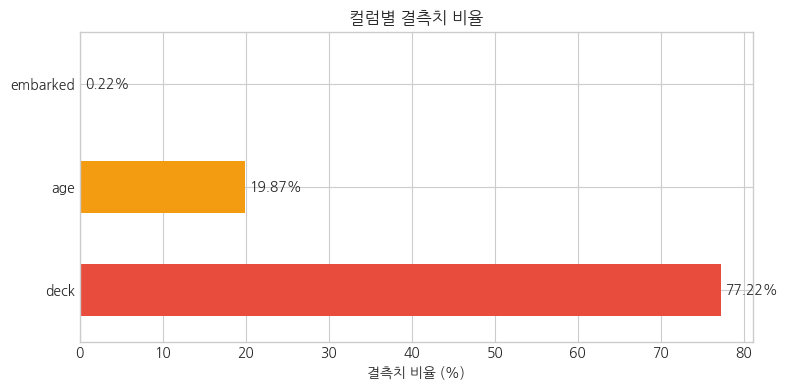

In [6]:
# 결측치 비율 분석
missing = pd.DataFrame({
    '결측치 수': df_raw.isnull().sum(),
    '결측치 비율(%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
}).sort_values('결측치 비율(%)', ascending=False)
missing = missing[missing['결측치 수'] > 0]
print('=== 결측치가 있는 컬럼 ===')
display(missing)

# 결측치 시각화
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 10 else '#3498db' for v in missing['결측치 비율(%)']]
missing['결측치 비율(%)'].plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('결측치 비율 (%)')
ax.set_title('컬럼별 결측치 비율')
for i, v in enumerate(missing['결측치 비율(%)']):
    ax.text(v + 0.5, i, f'{v}%', va='center')
plt.tight_layout()
plt.show()

### 2.2 이상치 탐색

In [7]:
# 수치형 변수 이상치 탐색 (IQR 방법)
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_no_target = [c for c in numeric_cols if c != TARGET]

print('=== IQR 기반 이상치 탐색 ===')
outlier_info = []
for col in numeric_cols_no_target:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_raw[(df_raw[col] < lower) | (df_raw[col] > upper)][col]
    outlier_info.append({
        '변수': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        '하한': round(lower, 2),
        '상한': round(upper, 2),
        '이상치 수': len(outliers),
        '이상치 비율(%)': round(len(outliers)/len(df_raw)*100, 2)
    })

pd.DataFrame(outlier_info)

=== IQR 기반 이상치 탐색 ===


,변수,Q1,Q3,IQR,하한,상한,이상치 수,이상치 비율(%)
0,pclass,2.00,3.0,1.00,0.50,4.50,0,0.00
1,age,20.12,38.0,17.88,-6.69,64.81,11,1.23
2,sibsp,0.00,1.0,1.00,-1.50,2.50,46,5.16
3,parch,0.00,0.0,0.00,0.00,0.00,213,23.91
4,fare,7.91,31.0,23.09,-26.72,65.63,116,13.02


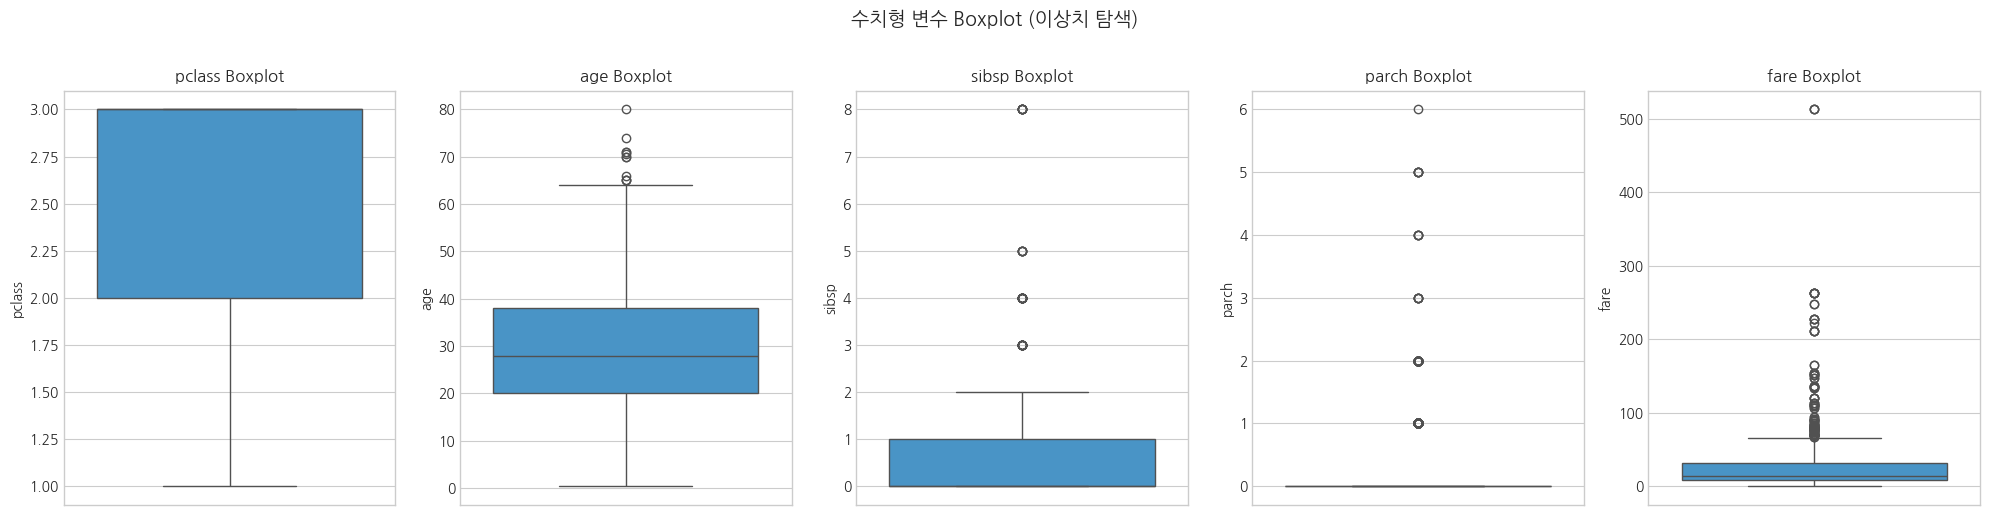

In [8]:
# Boxplot으로 이상치 시각화
fig, axes = plt.subplots(1, len(numeric_cols_no_target), figsize=(4*len(numeric_cols_no_target), 5))
for i, col in enumerate(numeric_cols_no_target):
    sns.boxplot(data=df_raw, y=col, ax=axes[i], color='#3498db')
    axes[i].set_title(f'{col} Boxplot')
plt.suptitle('수치형 변수 Boxplot (이상치 탐색)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.3 변수 분포 시각화 (Histogram)

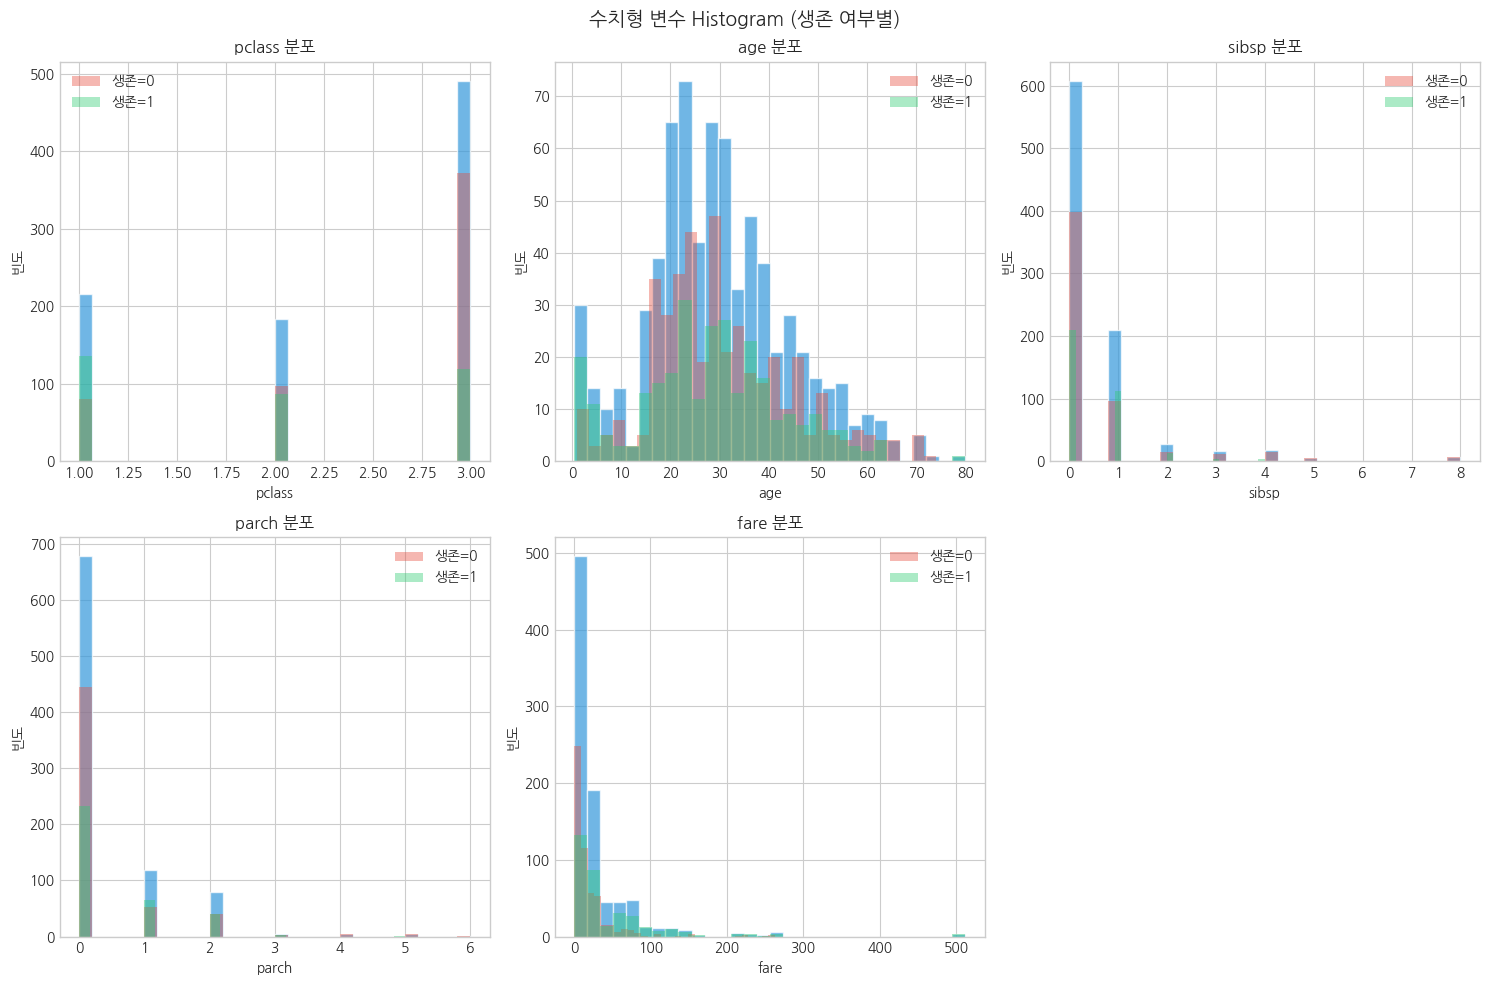

In [9]:
# Histogram - 수치형 변수 분포
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_no_target):
    axes[i].hist(df_raw[col].dropna(), bins=30, color='#3498db', edgecolor='white', alpha=0.7)
    axes[i].set_title(f'{col} 분포')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('빈도')
    # 생존 여부별 분포 오버레이
    for surv, color in [(0, '#e74c3c'), (1, '#2ecc71')]:
        axes[i].hist(df_raw[df_raw[TARGET]==surv][col].dropna(), bins=30,
                     color=color, alpha=0.4, label=f'생존={surv}')
    axes[i].legend()

# 빈 subplot 제거
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('수치형 변수 Histogram (생존 여부별)', fontsize=14)
plt.tight_layout()
plt.show()

### 2.4 범주형 변수 분포 (Countplot / Barplot)

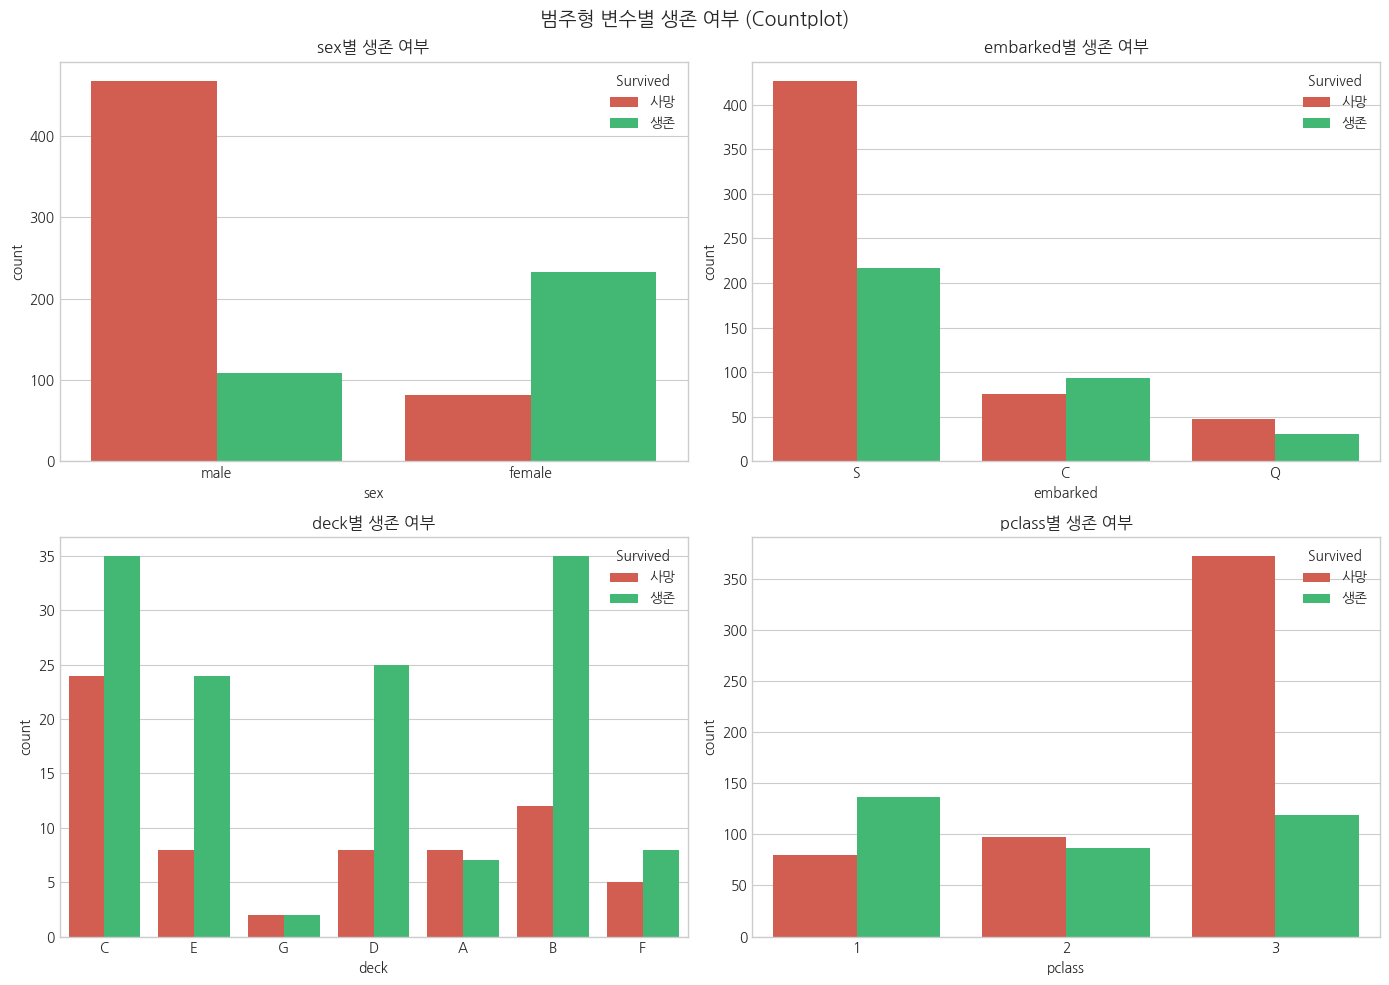

In [10]:
# Countplot - 범주형 변수
cat_cols = ['sex', 'embarked', 'deck', 'pclass']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data=df_raw, x=col, hue=TARGET, ax=axes[i], palette=['#e74c3c', '#2ecc71'])
    axes[i].set_title(f'{col}별 생존 여부')
    axes[i].legend(title='Survived', labels=['사망', '생존'])

plt.suptitle('범주형 변수별 생존 여부 (Countplot)', fontsize=14)
plt.tight_layout()
plt.show()

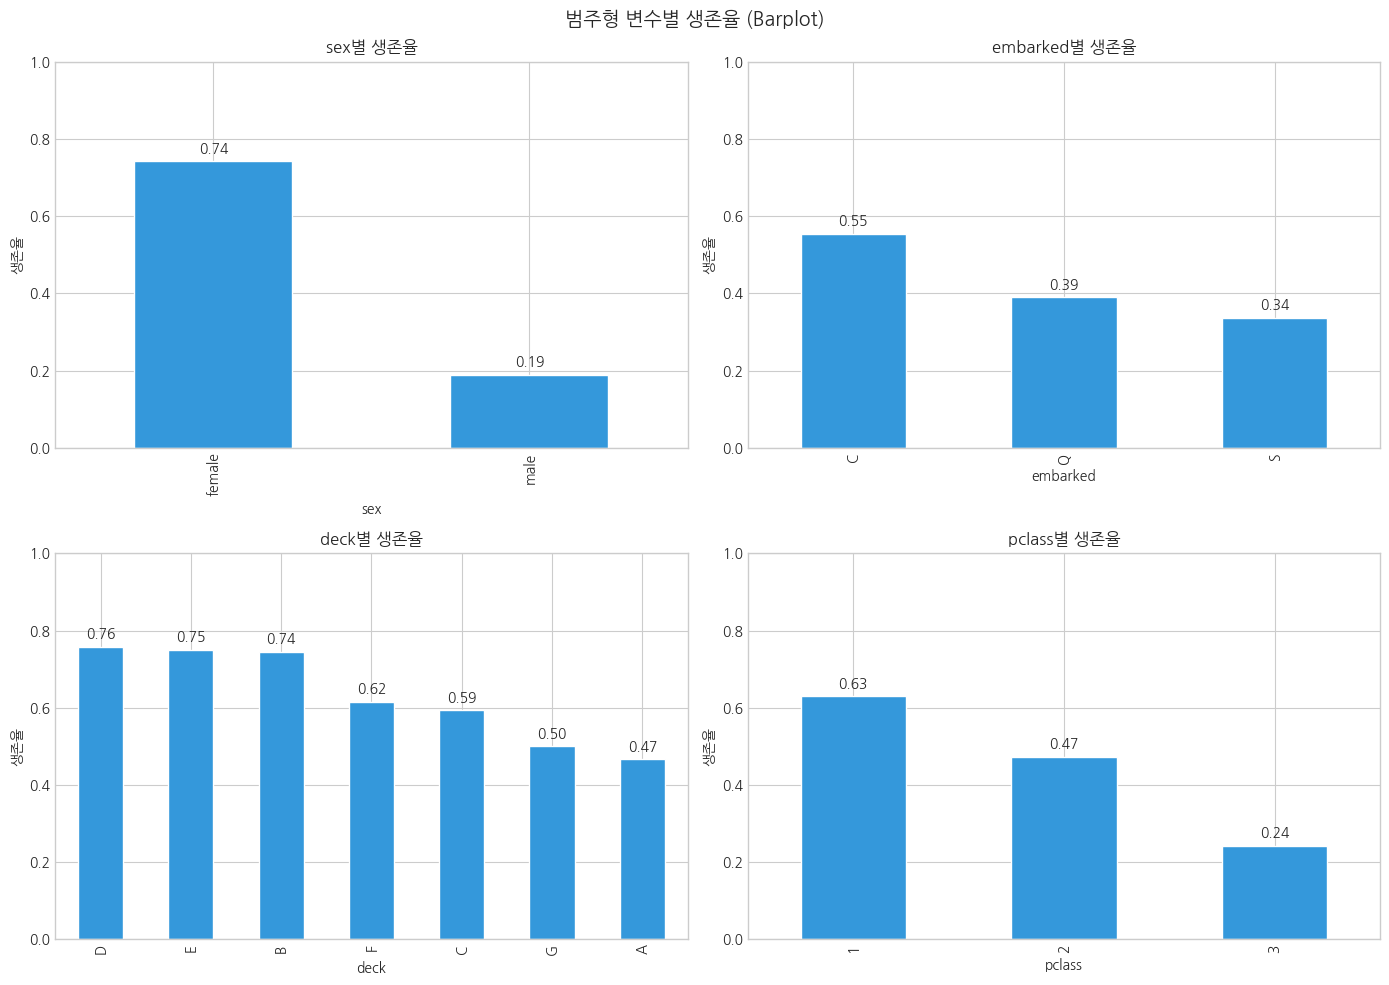

In [11]:
# Barplot - 범주형 변수별 생존율
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    survival_rate = df_raw.groupby(col)[TARGET].mean().sort_values(ascending=False)
    survival_rate.plot(kind='bar', ax=axes[i], color='#3498db', edgecolor='white')
    axes[i].set_title(f'{col}별 생존율')
    axes[i].set_ylabel('생존율')
    axes[i].set_ylim(0, 1)
    for j, v in enumerate(survival_rate):
        axes[i].text(j, v + 0.02, f'{v:.2f}', ha='center')

plt.suptitle('범주형 변수별 생존율 (Barplot)', fontsize=14)
plt.tight_layout()
plt.show()

### 2.5 상관관계 분석 (Heatmap)

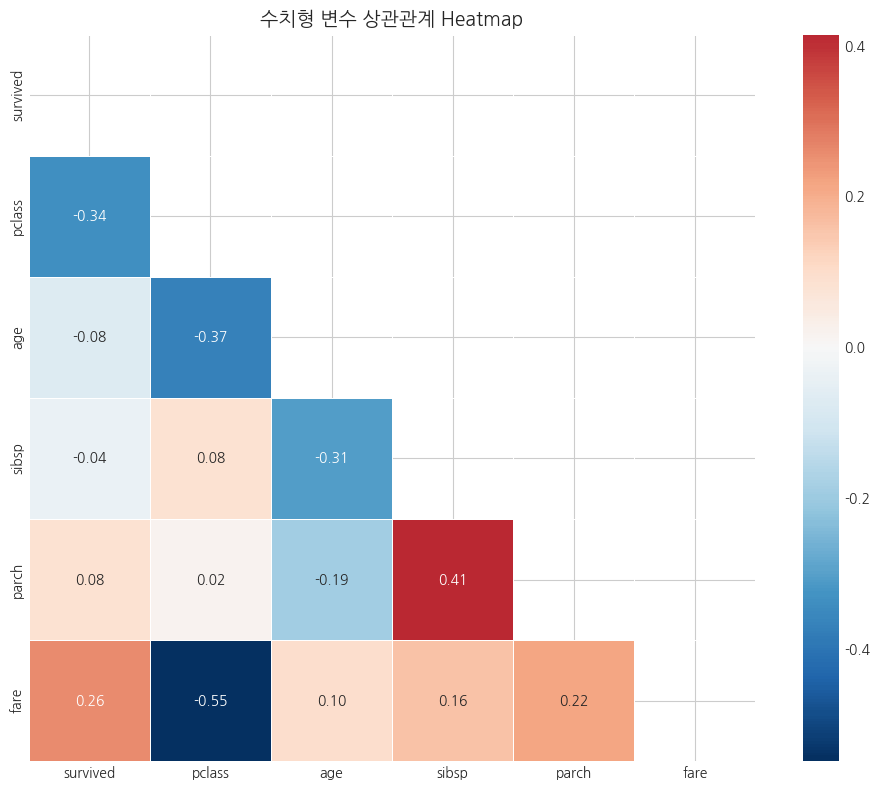


=== 타겟(survived)과의 상관관계 ===
fare      0.257
parch     0.082
sibsp    -0.035
age      -0.077
pclass   -0.338
Name: survived, dtype: float64


In [12]:
# Heatmap - 상관관계
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_raw[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('수치형 변수 상관관계 Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# 타겟과의 상관관계
print('\n=== 타겟(survived)과의 상관관계 ===')
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
print(target_corr.round(3))

### 2.6 타겟 변수 분포 확인

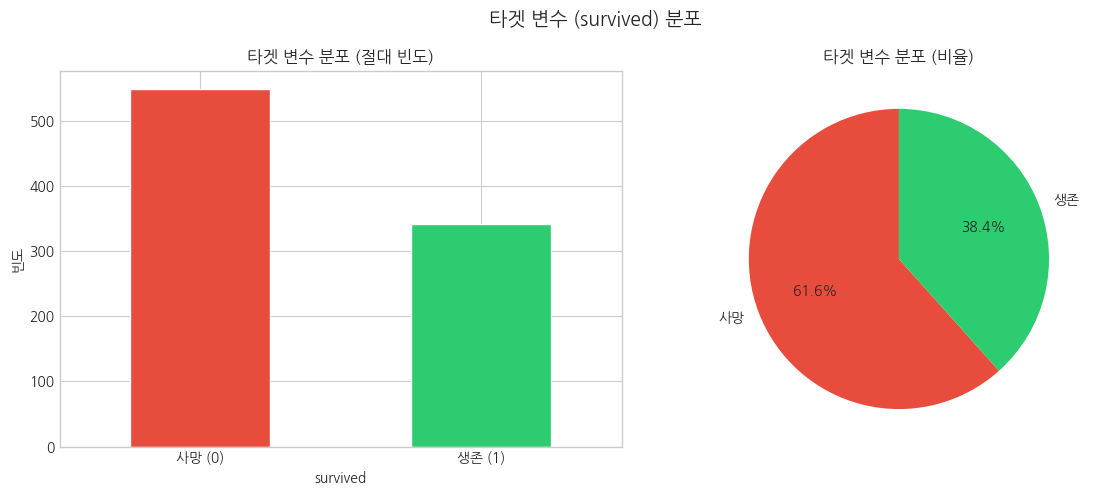

사망: 549명 (61.6%)
생존: 342명 (38.4%)


In [13]:
# 타겟 변수 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 절대 빈도
df_raw[TARGET].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'],
                                    edgecolor='white')
axes[0].set_title('타겟 변수 분포 (절대 빈도)')
axes[0].set_xticklabels(['사망 (0)', '생존 (1)'], rotation=0)
axes[0].set_ylabel('빈도')

# 비율
df_raw[TARGET].value_counts(normalize=True).plot(kind='pie', ax=axes[1],
    colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%', startangle=90,
    labels=['사망', '생존'])
axes[1].set_title('타겟 변수 분포 (비율)')
axes[1].set_ylabel('')

plt.suptitle('타겟 변수 (survived) 분포', fontsize=14)
plt.tight_layout()
plt.show()

print(f'사망: {(df_raw[TARGET]==0).sum()}명 ({(df_raw[TARGET]==0).mean()*100:.1f}%)')
print(f'생존: {(df_raw[TARGET]==1).sum()}명 ({(df_raw[TARGET]==1).mean()*100:.1f}%)')

### 2.7 EDA 분석 결과 요약

**데이터 품질 문제:**
- `deck`: 결측치 77.2%로 매우 높음 → 제거 고려
- `age`: 결측치 19.9% → 적절한 대체 필요
- `embarked`: 결측치 0.2% → 최빈값 대체 가능

**클래스 불균형:**
- 사망 61.6% vs 생존 38.4% → 약간의 불균형 존재하나 심각하지 않음

**주요 변수 특징:**
- `sex`: 여성의 생존율이 남성보다 현저히 높음
- `pclass`: 1등석 > 2등석 > 3등석 순으로 생존율 높음
- `fare`: 높은 운임일수록 생존율이 높은 경향
- `age`: 어린이(~10세)의 생존율이 비교적 높음
- `fare`에 이상치 다수 존재 (고가 티켓)
- `sibsp`, `parch`는 대부분 0에 집중

---
## STEP 03. 특성 공학 파이프라인 구현

### 3.0 기본 데이터 준비

In [14]:
# deck 컬럼은 결측치 77%이므로 제거하고 사용
df_work = df_raw.drop(columns=['deck']).copy()
print(f'작업 데이터 Shape: {df_work.shape}')
print(f'컬럼: {df_work.columns.tolist()}')
df_work.head()

작업 데이터 Shape: (891, 8)
컬럼: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### 3.4 파생 변수 생성 (Feature Creation)

In [15]:
def create_features(df):
    """파생 변수 생성 함수"""
    df = df.copy()

    # 1) Family Size: 가족 크기
    df['family_size'] = df['sibsp'] + df['parch'] + 1

    # 2) Is Alone: 혼자 탑승 여부
    df['is_alone'] = (df['family_size'] == 1).astype(int)

    # 3) Fare Per Person: 1인당 운임
    df['fare_per_person'] = df['fare'] / df['family_size']

    # 4) Age Group: 나이 그룹
    df['age_group'] = pd.cut(df['age'],
                             bins=[0, 12, 18, 35, 60, 100],
                             labels=['Child', 'Teen', 'Young', 'Middle', 'Senior'],
                             right=False)

    # 5) Title: 이름에서 호칭 추출은 불가(이름 컬럼 없음), 대신 Fare 구간
    df['fare_bin'] = pd.qcut(df['fare'], q=4, labels=['Low', 'Mid', 'High', 'VeryHigh'],
                              duplicates='drop')

    return df

df_feat = create_features(df_work)
print('생성된 파생 변수:')
print('- family_size: 가족 크기 (sibsp + parch + 1)')
print('- is_alone: 혼자 탑승 여부')
print('- fare_per_person: 1인당 운임 (fare / family_size)')
print('- age_group: 나이 그룹 (Child/Teen/Young/Middle/Senior)')
print('- fare_bin: 운임 구간 (Low/Mid/High/VeryHigh)')
print(f'\nShape: {df_feat.shape}')
df_feat.head()

생성된 파생 변수:
- family_size: 가족 크기 (sibsp + parch + 1)
- is_alone: 혼자 탑승 여부
- fare_per_person: 1인당 운임 (fare / family_size)
- age_group: 나이 그룹 (Child/Teen/Young/Middle/Senior)
- fare_bin: 운임 구간 (Low/Mid/High/VeryHigh)

Shape: (891, 13)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,family_size,is_alone,fare_per_person,age_group,fare_bin
0,0,3,male,22.0,1,0,7.2500,S,2,0,3.62500,Young,Low
1,1,1,female,38.0,1,0,71.2833,C,2,0,35.64165,Middle,VeryHigh
2,1,3,female,26.0,0,0,7.9250,S,1,1,7.92500,Young,Mid
3,1,1,female,35.0,1,0,53.1000,S,2,0,26.55000,Middle,VeryHigh
4,0,3,male,35.0,0,0,8.0500,S,1,1,8.05000,Middle,Mid


### 3.1 결측치 처리 비교

In [16]:
# 결측치 처리 전략 비교를 위한 함수
def prepare_data(df, missing_strategy='mean'):
    """
    결측치 처리 전략에 따라 데이터를 전처리
    missing_strategy: 'mean', 'median', 'most_frequent', 'drop'
    """
    df = df.copy()

    if missing_strategy == 'drop':
        df = df.dropna()
    else:
        # 수치형: mean or median
        num_cols = df.select_dtypes(include=[np.number]).columns
        for col in num_cols:
            if df[col].isnull().sum() > 0:
                if missing_strategy == 'mean':
                    df[col].fillna(df[col].mean(), inplace=True)
                elif missing_strategy == 'median':
                    df[col].fillna(df[col].median(), inplace=True)
                elif missing_strategy == 'most_frequent':
                    df[col].fillna(df[col].mode()[0], inplace=True)

        # 범주형: most_frequent
        cat_cols = df.select_dtypes(include=['object', 'category']).columns
        for col in cat_cols:
            if df[col].isnull().sum() > 0:
                df[col].fillna(df[col].mode()[0], inplace=True)

    return df

# 비교 실험
strategies = ['mean', 'median', 'most_frequent', 'drop']
missing_results = {}

for strategy in strategies:
    df_temp = prepare_data(df_feat, strategy)
    missing_results[strategy] = {
        '처리 후 데이터 수': len(df_temp),
        '남은 결측치': df_temp.isnull().sum().sum()
    }

print('=== 결측치 처리 전략 비교 ===')
pd.DataFrame(missing_results).T

=== 결측치 처리 전략 비교 ===


,처리 후 데이터 수,남은 결측치
mean,891,0
median,891,0
most_frequent,891,0
drop,712,0


### 3.2 범주형 인코딩 비교

In [17]:
def encode_data(df, encoding='onehot'):
    """
    인코딩 전략에 따라 범주형 변수를 변환
    encoding: 'onehot', 'label'
    """
    df = df.copy()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    if encoding == 'onehot':
        df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)
    elif encoding == 'label':
        le = LabelEncoder()
        for col in cat_cols:
            df[col] = df[col].astype(str)
            df[col] = le.fit_transform(df[col])

    return df

# 비교 시연
df_temp = prepare_data(df_feat, 'mean')

df_onehot = encode_data(df_temp, 'onehot')
df_label = encode_data(df_temp, 'label')

print(f'One-Hot Encoding 후 컬럼 수: {df_onehot.shape[1]}')
print(f'Label Encoding 후 컬럼 수: {df_label.shape[1]}')
print(f'\nOne-Hot 컬럼: {df_onehot.columns.tolist()}')

One-Hot Encoding 후 컬럼 수: 19
Label Encoding 후 컬럼 수: 13

One-Hot 컬럼: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone', 'fare_per_person', 'sex_male', 'embarked_Q', 'embarked_S', 'age_group_Teen', 'age_group_Young', 'age_group_Middle', 'age_group_Senior', 'fare_bin_Mid', 'fare_bin_High', 'fare_bin_VeryHigh']


### 3.3 스케일링 비교

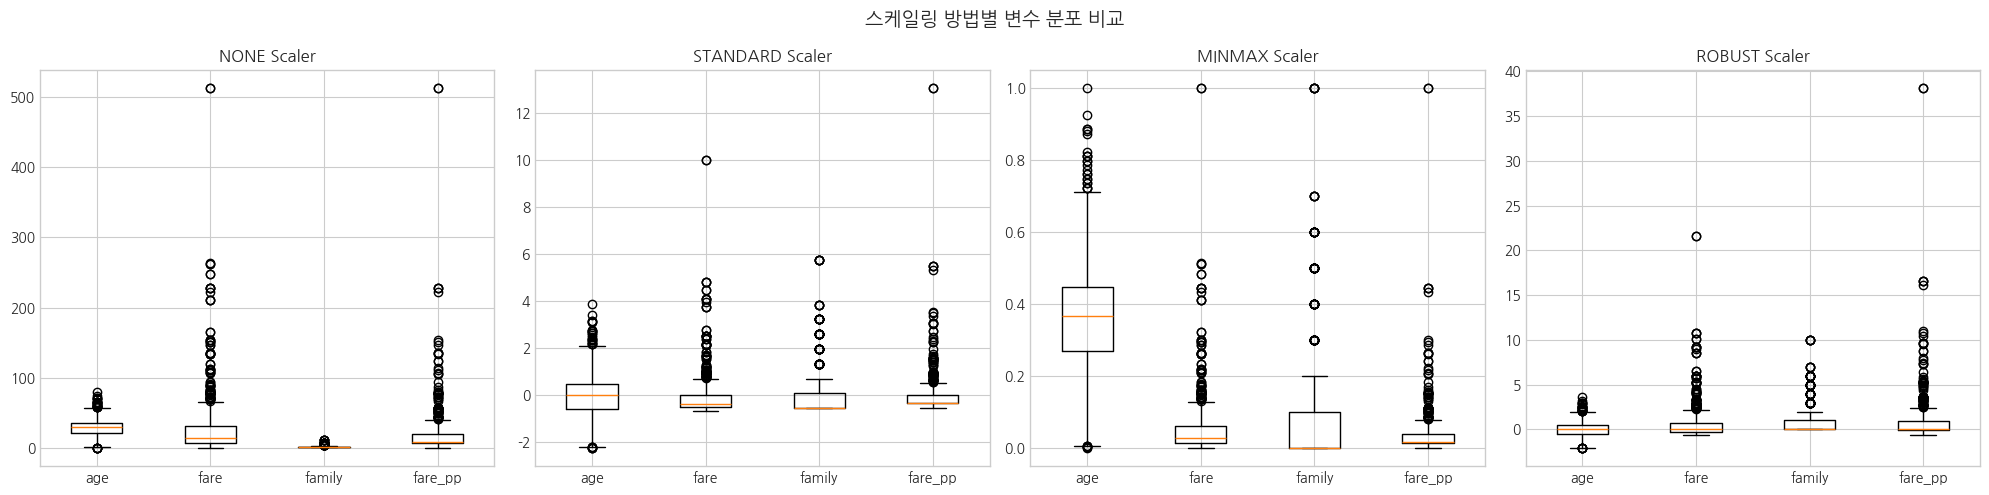

In [18]:
def scale_data(X_train, X_test, scaler_type='standard'):
    """
    스케일링 전략에 따라 수치형 데이터를 변환
    scaler_type: 'standard', 'minmax', 'robust', 'none'
    """
    if scaler_type == 'none':
        return X_train, X_test, None

    scalers = {
        'standard': StandardScaler(),
        'minmax': MinMaxScaler(),
        'robust': RobustScaler()
    }
    scaler = scalers[scaler_type]
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
                                   columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test),
                                  columns=X_test.columns, index=X_test.index)
    return X_train_scaled, X_test_scaled, scaler

# 스케일링 비교 시각화
df_temp = prepare_data(df_feat, 'mean')
df_encoded = encode_data(df_temp, 'onehot')
X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
scaler_names = ['none', 'standard', 'minmax', 'robust']
for i, sc in enumerate(scaler_names):
    X_tr, _, _ = scale_data(X_train, X_test, sc)
    axes[i].boxplot(X_tr[['age', 'fare', 'family_size', 'fare_per_person']].values,
                    labels=['age', 'fare', 'family', 'fare_pp'])
    axes[i].set_title(f'{sc.upper()} Scaler')

plt.suptitle('스케일링 방법별 변수 분포 비교', fontsize=14)
plt.tight_layout()
plt.show()

---
## STEP 04. 변수 선택 (Feature Selection)

In [19]:
# Feature Selection을 위한 데이터 준비
df_fs = prepare_data(df_feat, 'median')
df_fs = encode_data(df_fs, 'onehot')
X_all = df_fs.drop(columns=[TARGET])
y_all = df_fs[TARGET]
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

### 4.1 Random Forest Feature Importance

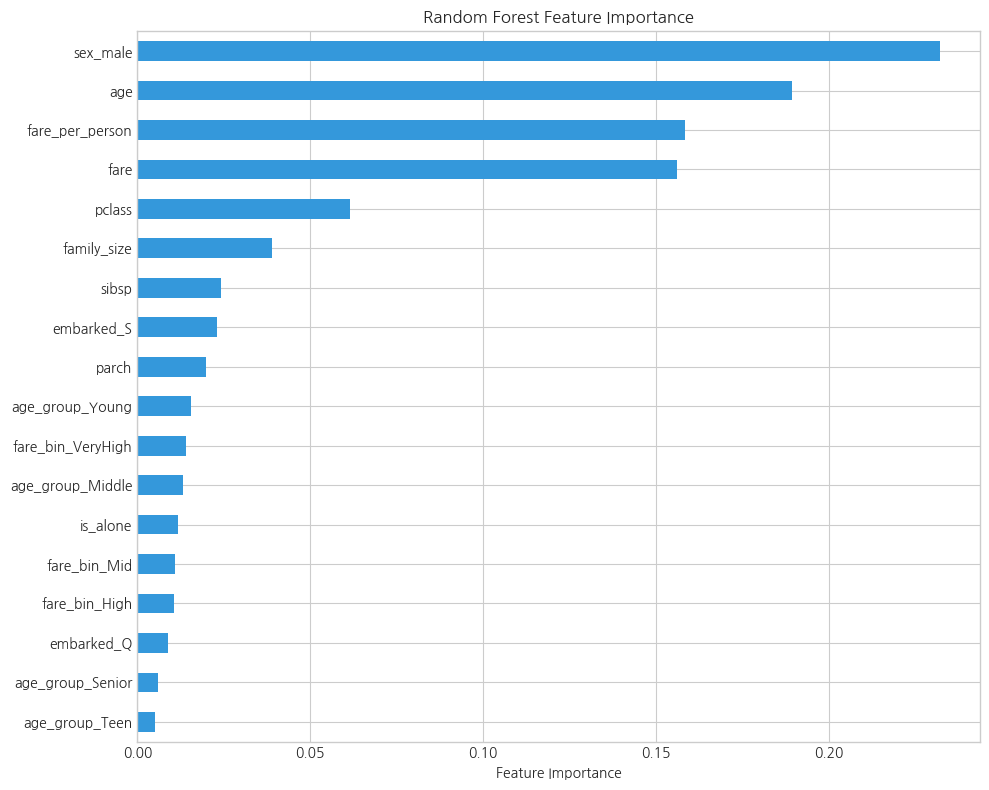


=== Top 10 중요 변수 ===
sex_male           0.2322
age                0.1895
fare_per_person    0.1585
fare               0.1561
pclass             0.0614
family_size        0.0388
sibsp              0.0243
embarked_S         0.0231
parch              0.0199
age_group_Young    0.0155
dtype: float64


In [20]:
# Random Forest Feature Importance
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_tr, y_tr)

feat_imp = pd.Series(rf_model.feature_importances_, index=X_tr.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.plot(kind='barh', ax=ax, color='#3498db')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\n=== Top 10 중요 변수 ===')
print(feat_imp.head(10).round(4))

### 4.2 SelectKBest (f_classif)

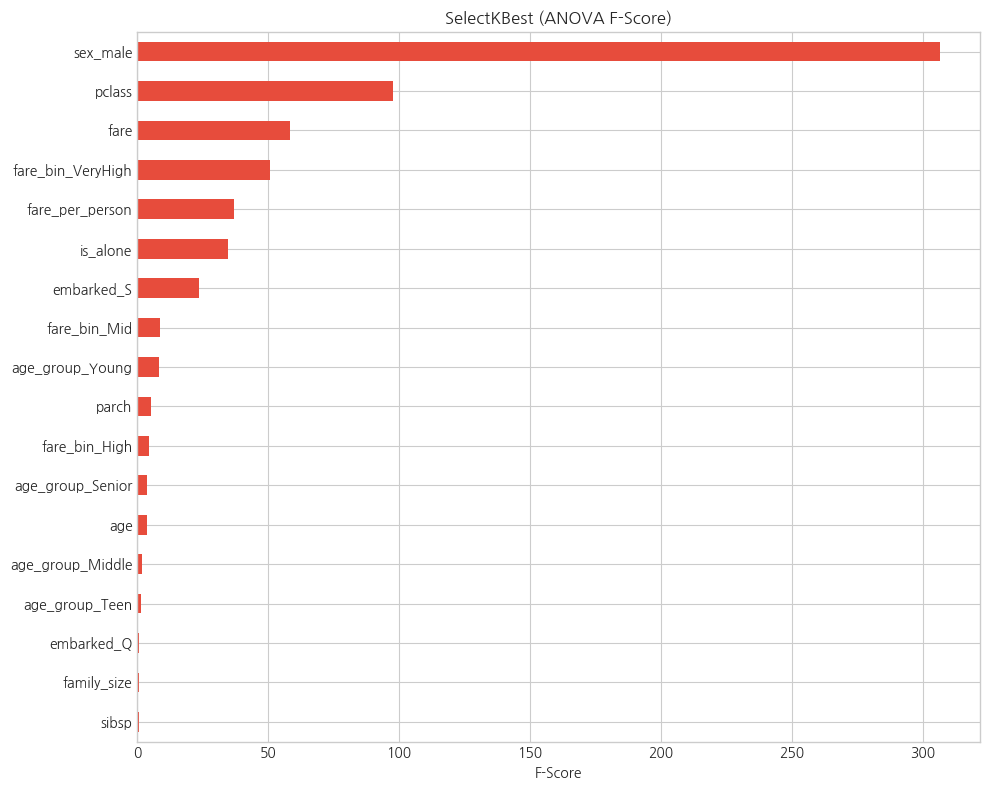


=== Top 10 변수 (F-Score) ===
sex_male             306.59
pclass                97.84
fare                  58.31
fare_bin_VeryHigh     50.60
fare_per_person       36.80
is_alone              34.60
embarked_S            23.55
fare_bin_Mid           8.51
age_group_Young        8.36
parch                  5.07
dtype: float64


In [21]:
# SelectKBest
selector = SelectKBest(f_classif, k='all')
selector.fit(X_tr, y_tr)

kbest_scores = pd.Series(selector.scores_, index=X_tr.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
kbest_scores.plot(kind='barh', ax=ax, color='#e74c3c')
ax.set_xlabel('F-Score')
ax.set_title('SelectKBest (ANOVA F-Score)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\n=== Top 10 변수 (F-Score) ===')
print(kbest_scores.head(10).round(2))

### 4.3 RFE (Recursive Feature Elimination)

In [22]:
# RFE
rfe = RFE(estimator=LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=8)
rfe.fit(StandardScaler().fit_transform(X_tr), y_tr)

rfe_ranking = pd.Series(rfe.ranking_, index=X_tr.columns).sort_values()
selected_rfe = X_tr.columns[rfe.support_].tolist()

print('=== RFE 선택된 변수 (Top 8) ===')
print(selected_rfe)
print(f'\n선택된 변수 수: {len(selected_rfe)}')

=== RFE 선택된 변수 (Top 8) ===
['pclass', 'age', 'family_size', 'is_alone', 'sex_male', 'age_group_Young', 'fare_bin_High', 'fare_bin_VeryHigh']

선택된 변수 수: 8


### 4.4 Feature Selection 전/후 성능 비교

In [23]:
# 상위 N개 변수 선정 (RF Importance 기준)
TOP_N = 10
top_features = feat_imp.head(TOP_N).index.tolist()
print(f'선정된 상위 {TOP_N}개 변수: {top_features}')

# 전체 변수 vs 선택된 변수 성능 비교
X_tr_scaled, X_te_scaled, _ = scale_data(X_tr, X_te, 'standard')

results_fs = {}
for name, X_tr_use, X_te_use in [
    ('전체 변수', X_tr_scaled, X_te_scaled),
    (f'상위 {TOP_N}개', X_tr_scaled[top_features], X_te_scaled[top_features])
]:
    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf.fit(X_tr_use, y_tr)
    y_pred = rf.predict(X_te_use)
    y_prob = rf.predict_proba(X_te_use)[:, 1]
    results_fs[name] = {
        '변수 수': X_tr_use.shape[1],
        'Accuracy': round(accuracy_score(y_te, y_pred), 4),
        'F1-Score': round(f1_score(y_te, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_te, y_prob), 4)
    }

print('\n=== Feature Selection 전/후 성능 비교 ===')
pd.DataFrame(results_fs).T

선정된 상위 10개 변수: ['sex_male', 'age', 'fare_per_person', 'fare', 'pclass', 'family_size', 'sibsp', 'embarked_S', 'parch', 'age_group_Young']



=== Feature Selection 전/후 성능 비교 ===


,변수 수,Accuracy,F1-Score,ROC-AUC
전체 변수,18.0,0.7765,0.7101,0.8082
상위 10개,10.0,0.7933,0.7218,0.8138


---
## STEP 05. 모델 학습 및 평가

### 5.1 실험 설계

| 실험 | 결측치 처리 | 인코딩 | 스케일링 | Feature Selection |
|------|------------|--------|---------|-------------------|
| Base | 없음 | 없음 | 없음 | 없음 |
| Exp-1 | Mean | One-Hot | Standard | X |
| Exp-2 | Median | Label | MinMax | O |
| Exp-3 | Most Frequent | One-Hot | Robust | O |

In [24]:
def run_experiment(df_feat, missing_strategy, encoding, scaler_type,
                   use_feature_selection=False, top_n=10):
    """
    실험 파이프라인: 결측치 처리 → 인코딩 → 스케일링 → (Feature Selection) → 모델 학습/평가
    """
    # 1. 결측치 처리
    if missing_strategy == 'none':
        df_proc = df_feat.dropna()
    else:
        df_proc = prepare_data(df_feat, missing_strategy)

    # 2. 인코딩
    if encoding == 'none':
        # Base: 수치형만 사용
        num_cols = df_proc.select_dtypes(include=[np.number]).columns.tolist()
        df_proc = df_proc[num_cols]
    else:
        df_proc = encode_data(df_proc, encoding)

    # 3. Train/Test Split
    X = df_proc.drop(columns=[TARGET])
    y = df_proc[TARGET]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    # 4. 스케일링
    X_train, X_test, _ = scale_data(X_train, X_test, scaler_type)

    # 5. Feature Selection (RF Importance 기준)
    if use_feature_selection:
        rf_sel = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_sel.fit(X_train, y_train)
        imp = pd.Series(rf_sel.feature_importances_, index=X_train.columns)
        top_feats = imp.nlargest(min(top_n, len(imp))).index.tolist()
        X_train = X_train[top_feats]
        X_test = X_test[top_feats]

    # 6. 모델 학습 및 평가
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
        'XGBoost': XGBClassifier(n_estimators=200, random_state=42,
                                  eval_metric='logloss', verbosity=0),
        'LightGBM': LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)
    }

    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        results[name] = {
            'Accuracy': round(accuracy_score(y_test, y_pred), 4),
            'Precision': round(precision_score(y_test, y_pred), 4),
            'Recall': round(recall_score(y_test, y_pred), 4),
            'F1-Score': round(f1_score(y_test, y_pred), 4),
            'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
        }

    return results, X_train, X_test, y_train, y_test, models

print('실험 함수 정의 완료')

실험 함수 정의 완료


In [25]:
# ============================================
# 실험 실행
# ============================================

experiments = {
    'Base': {'missing_strategy': 'none', 'encoding': 'none',
             'scaler_type': 'none', 'use_feature_selection': False},
    'Exp-1 (Mean/OneHot/Std/NoFS)': {'missing_strategy': 'mean', 'encoding': 'onehot',
             'scaler_type': 'standard', 'use_feature_selection': False},
    'Exp-2 (Median/Label/MinMax/FS)': {'missing_strategy': 'median', 'encoding': 'label',
             'scaler_type': 'minmax', 'use_feature_selection': True},
    'Exp-3 (Freq/OneHot/Robust/FS)': {'missing_strategy': 'most_frequent', 'encoding': 'onehot',
             'scaler_type': 'robust', 'use_feature_selection': True},
}

all_results = {}
best_exp_data = None

for exp_name, params in experiments.items():
    print(f'\n{"="*60}')
    print(f'실험: {exp_name}')
    print(f'설정: {params}')
    print(f'{"="*60}')

    results, X_tr_exp, X_te_exp, y_tr_exp, y_te_exp, models_exp = run_experiment(df_feat, **params)
    all_results[exp_name] = results

    result_df = pd.DataFrame(results).T
    display(result_df)

    # Exp-3 데이터 저장 (가산점용)
    if 'Exp-3' in exp_name:
        best_exp_data = (X_tr_exp, X_te_exp, y_tr_exp, y_te_exp, models_exp)


실험: Base
설정: {'missing_strategy': 'none', 'encoding': 'none', 'scaler_type': 'none', 'use_feature_selection': False}


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.7063,0.6818,0.5172,0.5882,0.7351
Random Forest,0.6503,0.5625,0.6207,0.5902,0.7559
XGBoost,0.6503,0.5606,0.6379,0.5968,0.7444
LightGBM,0.6783,0.5968,0.6379,0.6167,0.7400



실험: Exp-1 (Mean/OneHot/Std/NoFS)
설정: {'missing_strategy': 'mean', 'encoding': 'onehot', 'scaler_type': 'standard', 'use_feature_selection': False}


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8156,0.7903,0.7101,0.7481,0.8489
Random Forest,0.7654,0.6957,0.6957,0.6957,0.8093
XGBoost,0.8101,0.7778,0.7101,0.7424,0.7963
LightGBM,0.7877,0.7385,0.6957,0.7164,0.8055



실험: Exp-2 (Median/Label/MinMax/FS)
설정: {'missing_strategy': 'median', 'encoding': 'label', 'scaler_type': 'minmax', 'use_feature_selection': True}


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8045,0.7742,0.6957,0.7328,0.8527
Random Forest,0.7933,0.7353,0.7246,0.7299,0.8246
XGBoost,0.7877,0.7460,0.6812,0.7121,0.7937
LightGBM,0.7933,0.7424,0.7101,0.7259,0.8057



실험: Exp-3 (Freq/OneHot/Robust/FS)
설정: {'missing_strategy': 'most_frequent', 'encoding': 'onehot', 'scaler_type': 'robust', 'use_feature_selection': True}


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8156,0.8000,0.6957,0.7442,0.8486
Random Forest,0.8101,0.7692,0.7246,0.7463,0.8194
XGBoost,0.8156,0.7812,0.7246,0.7519,0.8069
LightGBM,0.8156,0.7727,0.7391,0.7556,0.8182


### 5.2 실험 결과 종합 비교표

In [26]:
# 종합 비교표 생성
comparison_rows = []
for exp_name, results in all_results.items():
    for model_name, metrics in results.items():
        row = {'실험': exp_name, '모델': model_name}
        row.update(metrics)
        comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
print('=== 전체 실험 종합 비교표 ===')
display(comparison_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True))

=== 전체 실험 종합 비교표 ===


,실험,모델,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Exp-2 (Median/Label/MinMax/FS),Logistic Regression,0.8045,0.7742,0.6957,0.7328,0.8527
1,Exp-1 (Mean/OneHot/Std/NoFS),Logistic Regression,0.8156,0.7903,0.7101,0.7481,0.8489
2,Exp-3 (Freq/OneHot/Robust/FS),Logistic Regression,0.8156,0.8000,0.6957,0.7442,0.8486
3,Exp-2 (Median/Label/MinMax/FS),Random Forest,0.7933,0.7353,0.7246,0.7299,0.8246
4,Exp-3 (Freq/OneHot/Robust/FS),Random Forest,0.8101,0.7692,0.7246,0.7463,0.8194
5,Exp-3 (Freq/OneHot/Robust/FS),LightGBM,0.8156,0.7727,0.7391,0.7556,0.8182
6,Exp-1 (Mean/OneHot/Std/NoFS),Random Forest,0.7654,0.6957,0.6957,0.6957,0.8093
7,Exp-3 (Freq/OneHot/Robust/FS),XGBoost,0.8156,0.7812,0.7246,0.7519,0.8069
8,Exp-2 (Median/Label/MinMax/FS),LightGBM,0.7933,0.7424,0.7101,0.7259,0.8057
9,Exp-1 (Mean/OneHot/Std/NoFS),LightGBM,0.7877,0.7385,0.6957,0.7164,0.8055


In [27]:
# 실험별 최고 성능 비교
print('\n=== 실험별 최고 성능 (ROC-AUC 기준) ===')
for exp_name, results in all_results.items():
    best_model = max(results, key=lambda x: results[x]['ROC-AUC'])
    best_auc = results[best_model]['ROC-AUC']
    print(f'{exp_name}: {best_model} (ROC-AUC = {best_auc})')


=== 실험별 최고 성능 (ROC-AUC 기준) ===
Base: Random Forest (ROC-AUC = 0.7559)
Exp-1 (Mean/OneHot/Std/NoFS): Logistic Regression (ROC-AUC = 0.8489)
Exp-2 (Median/Label/MinMax/FS): Logistic Regression (ROC-AUC = 0.8527)
Exp-3 (Freq/OneHot/Robust/FS): Logistic Regression (ROC-AUC = 0.8486)


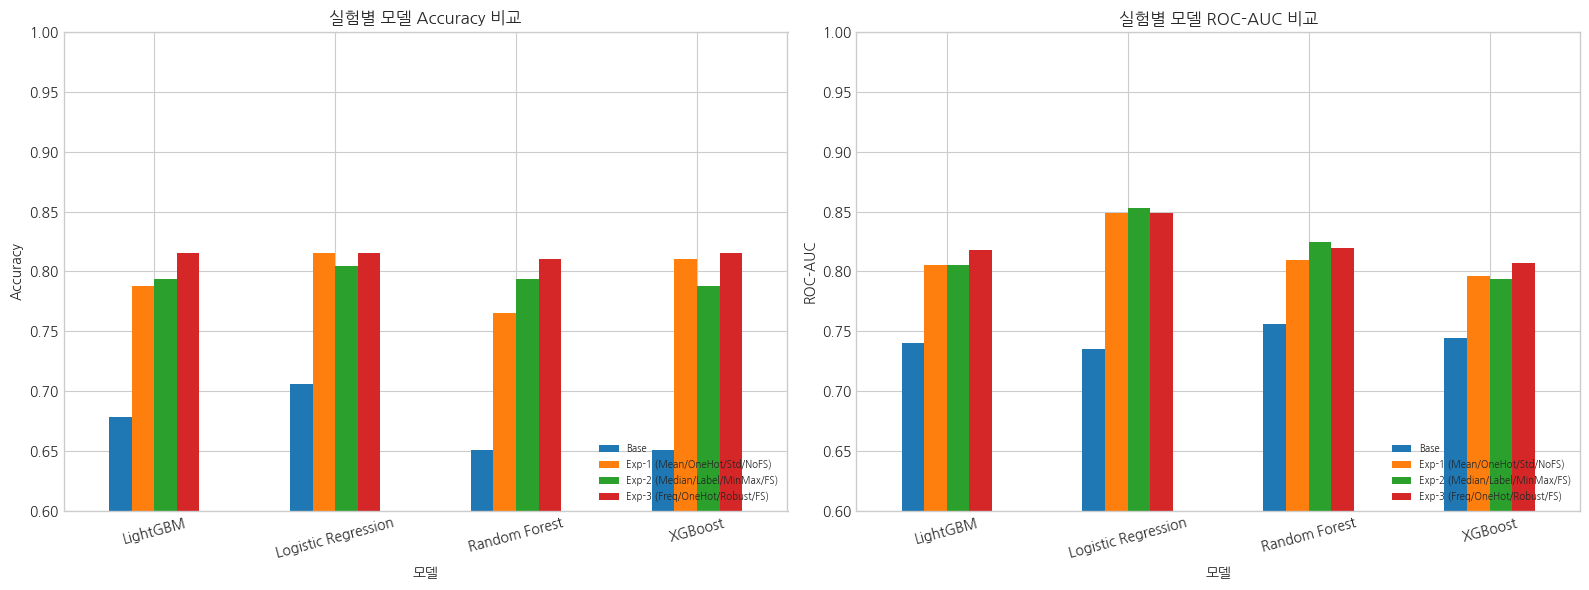

In [28]:
# 성능 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy 비교
pivot_acc = comparison_df.pivot(index='모델', columns='실험', values='Accuracy')
pivot_acc.plot(kind='bar', ax=axes[0], rot=15)
axes[0].set_title('실험별 모델 Accuracy 비교')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=7, loc='lower right')
axes[0].set_ylim(0.6, 1.0)

# ROC-AUC 비교
pivot_auc = comparison_df.pivot(index='모델', columns='실험', values='ROC-AUC')
pivot_auc.plot(kind='bar', ax=axes[1], rot=15)
axes[1].set_title('실험별 모델 ROC-AUC 비교')
axes[1].set_ylabel('ROC-AUC')
axes[1].legend(fontsize=7, loc='lower right')
axes[1].set_ylim(0.6, 1.0)

plt.tight_layout()
plt.show()

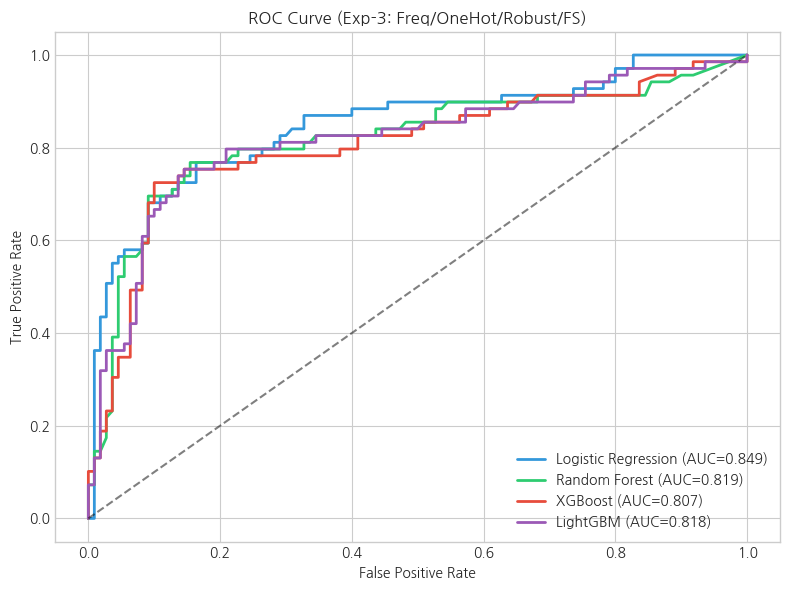

In [29]:
# ROC Curve (Exp-3 기준)
if best_exp_data:
    X_tr_best, X_te_best, y_tr_best, y_te_best, models_best = best_exp_data

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

    for (name, model), color in zip(models_best.items(), colors):
        y_prob = model.predict_proba(X_te_best)[:, 1]
        fpr, tpr, _ = roc_curve(y_te_best, y_prob)
        auc = roc_auc_score(y_te_best, y_prob)
        ax.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})', linewidth=2)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve (Exp-3: Freq/OneHot/Robust/FS)')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

---
## 가산점 항목

### 가산점 1: Pipeline 객체 활용

In [30]:
# sklearn Pipeline + ColumnTransformer 활용
from sklearn.preprocessing import OneHotEncoder

# 파생변수가 포함된 데이터 준비
df_pipe = df_work.copy()
df_pipe['family_size'] = df_pipe['sibsp'] + df_pipe['parch'] + 1
df_pipe['is_alone'] = (df_pipe['family_size'] == 1).astype(int)
df_pipe['fare_per_person'] = df_pipe['fare'] / df_pipe['family_size']

X_pipe = df_pipe.drop(columns=[TARGET])
y_pipe = df_pipe[TARGET]

num_features = ['age', 'sibsp', 'parch', 'fare', 'family_size', 'fare_per_person']
cat_features = ['sex', 'embarked']

# 수치형 파이프라인
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# 범주형 파이프라인
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features)
])

# 전체 파이프라인 (전처리 + 모델)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

# 학습 및 평가
X_tr_pipe, X_te_pipe, y_tr_pipe, y_te_pipe = train_test_split(
    X_pipe, y_pipe, test_size=0.2, random_state=42, stratify=y_pipe)

full_pipeline.fit(X_tr_pipe, y_tr_pipe)
y_pred_pipe = full_pipeline.predict(X_te_pipe)
y_prob_pipe = full_pipeline.predict_proba(X_te_pipe)[:, 1]

print('=== Pipeline 모델 성능 ===')
print(f'Accuracy:  {accuracy_score(y_te_pipe, y_pred_pipe):.4f}')
print(f'Precision: {precision_score(y_te_pipe, y_pred_pipe):.4f}')
print(f'Recall:    {recall_score(y_te_pipe, y_pred_pipe):.4f}')
print(f'F1-Score:  {f1_score(y_te_pipe, y_pred_pipe):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_te_pipe, y_prob_pipe):.4f}')

print('\n=== Pipeline 구조 ===')
print(full_pipeline)

=== Pipeline 모델 성능 ===
Accuracy:  0.7765
Precision: 0.7302
Recall:    0.6667
F1-Score:  0.6970
ROC-AUC:   0.8124

=== Pipeline 구조 ===
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'sibsp', 'parch',
                                                   'fare', 'family_size',
                                                   'fare_per_person']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImp

### 가산점 2: GridSearchCV 적용

In [31]:
# GridSearchCV - 파이프라인에 적용
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_tr_pipe, y_tr_pipe)

print(f'\n최적 파라미터: {grid_search.best_params_}')
print(f'최적 CV ROC-AUC: {grid_search.best_score_:.4f}')

# 최적 모델로 테스트 평가
y_pred_grid = grid_search.predict(X_te_pipe)
y_prob_grid = grid_search.predict_proba(X_te_pipe)[:, 1]

print(f'\n=== GridSearchCV 최적 모델 테스트 성능 ===')
print(f'Accuracy:  {accuracy_score(y_te_pipe, y_pred_grid):.4f}')
print(f'Precision: {precision_score(y_te_pipe, y_pred_grid):.4f}')
print(f'Recall:    {recall_score(y_te_pipe, y_pred_grid):.4f}')
print(f'F1-Score:  {f1_score(y_te_pipe, y_pred_grid):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_te_pipe, y_prob_grid):.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits



최적 파라미터: {'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
최적 CV ROC-AUC: 0.8749

=== GridSearchCV 최적 모델 테스트 성능 ===
Accuracy:  0.8101
Precision: 0.7966
Recall:    0.6812
F1-Score:  0.7344
ROC-AUC:   0.8389


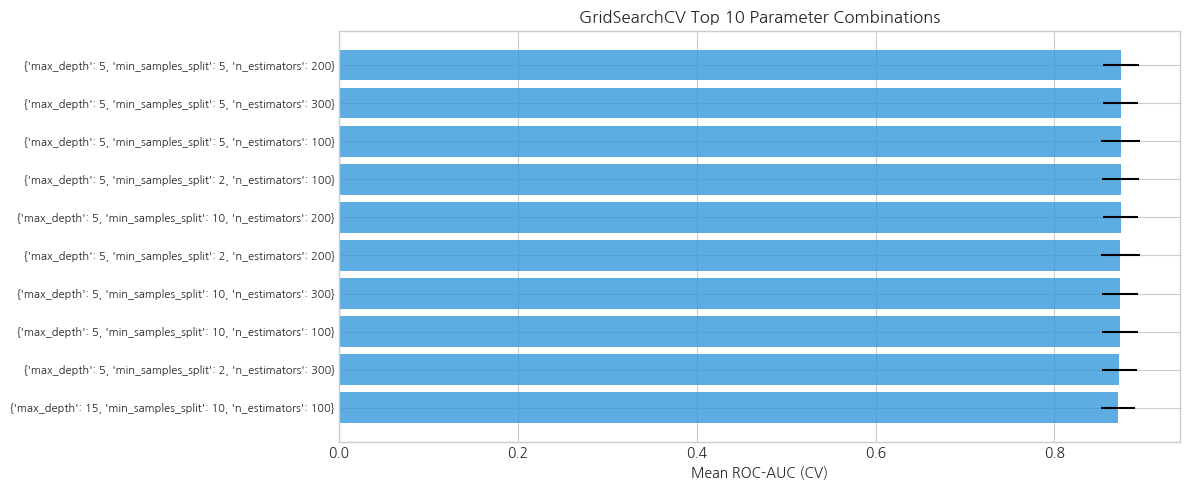

In [32]:
# GridSearchCV 결과 시각화
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values('rank_test_score')

fig, ax = plt.subplots(figsize=(12, 5))
top_10 = cv_results.head(10)
params_str = [str({k.replace('classifier__', ''): v for k, v in eval(p).items()})
              for p in top_10['params'].astype(str)]
ax.barh(range(10), top_10['mean_test_score'], xerr=top_10['std_test_score'],
        color='#3498db', alpha=0.8)
ax.set_yticks(range(10))
ax.set_yticklabels(params_str, fontsize=8)
ax.set_xlabel('Mean ROC-AUC (CV)')
ax.set_title('GridSearchCV Top 10 Parameter Combinations')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 가산점 3: SHAP 기반 설명 가능성 분석

=== SHAP Summary Plot (생존 클래스) ===


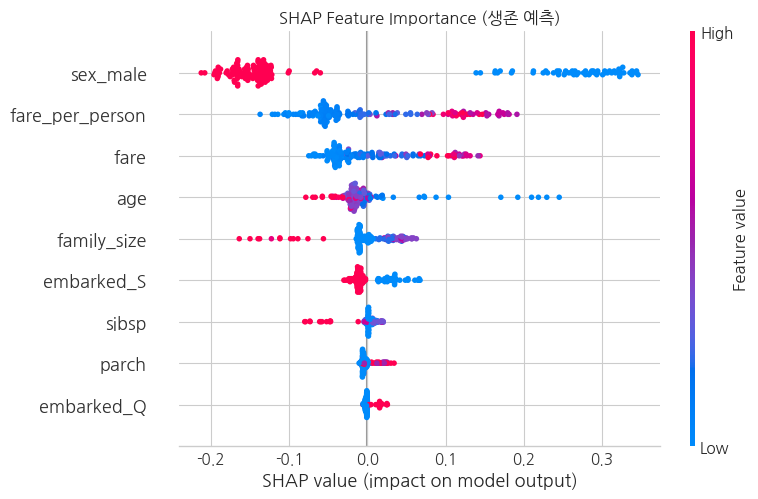

In [33]:
# SHAP 분석
# 파이프라인에서 전처리된 데이터 추출
X_tr_transformed = full_pipeline.named_steps['preprocessor'].transform(X_tr_pipe)
X_te_transformed = full_pipeline.named_steps['preprocessor'].transform(X_te_pipe)

# feature names 추출
ohe = full_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
cat_feature_names = ohe.get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + cat_feature_names

X_tr_df = pd.DataFrame(X_tr_transformed, columns=all_feature_names)
X_te_df = pd.DataFrame(X_te_transformed, columns=all_feature_names)

# SHAP TreeExplainer
best_model = grid_search.best_estimator_.named_steps['classifier']
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_te_df)

# SHAP Summary Plot
print('=== SHAP Summary Plot (생존 클래스) ===')
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values[:, :, 1], X_te_df, show=False, max_display=15)
plt.title('SHAP Feature Importance (생존 예측)')
plt.tight_layout()
plt.show()

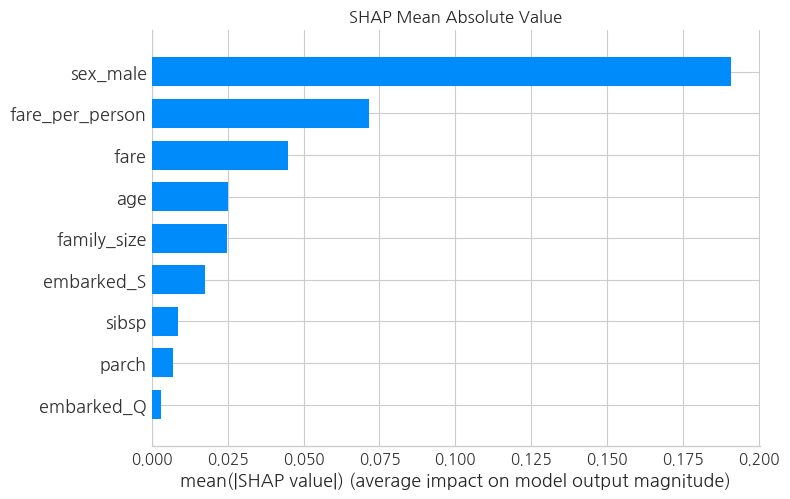

In [34]:
# SHAP Bar Plot
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 1], X_te_df, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Mean Absolute Value')
plt.tight_layout()
plt.show()

=== 개별 예측 설명 (첫 번째 테스트 샘플) ===


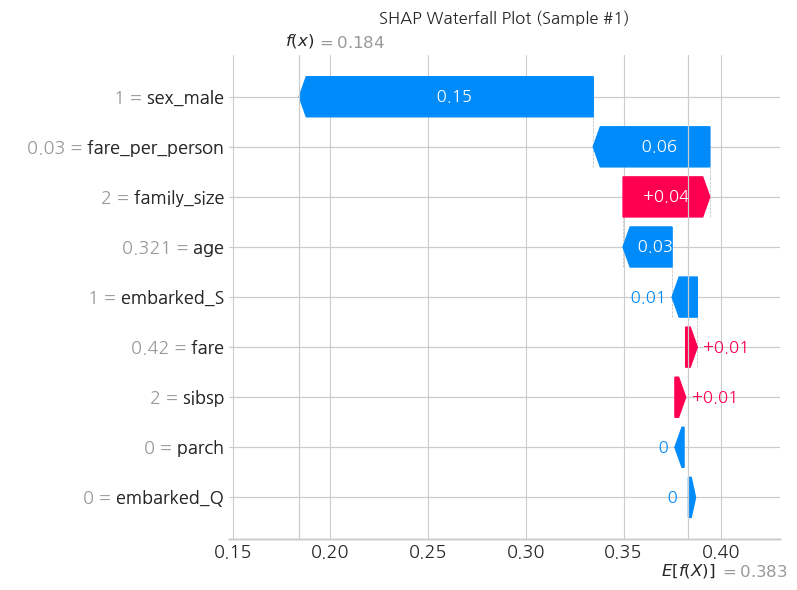

In [35]:
# SHAP Waterfall Plot (개별 예측 설명)
print('=== 개별 예측 설명 (첫 번째 테스트 샘플) ===')
shap_explanation = shap.Explanation(
    values=shap_values[0, :, 1],
    base_values=explainer.expected_value[1],
    data=X_te_df.iloc[0].values,
    feature_names=all_feature_names
)
fig, ax = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(shap_explanation, show=False, max_display=15)
plt.title('SHAP Waterfall Plot (Sample #1)')
plt.tight_layout()
plt.show()

### 가산점 4: Feature Importance 시각화 고도화

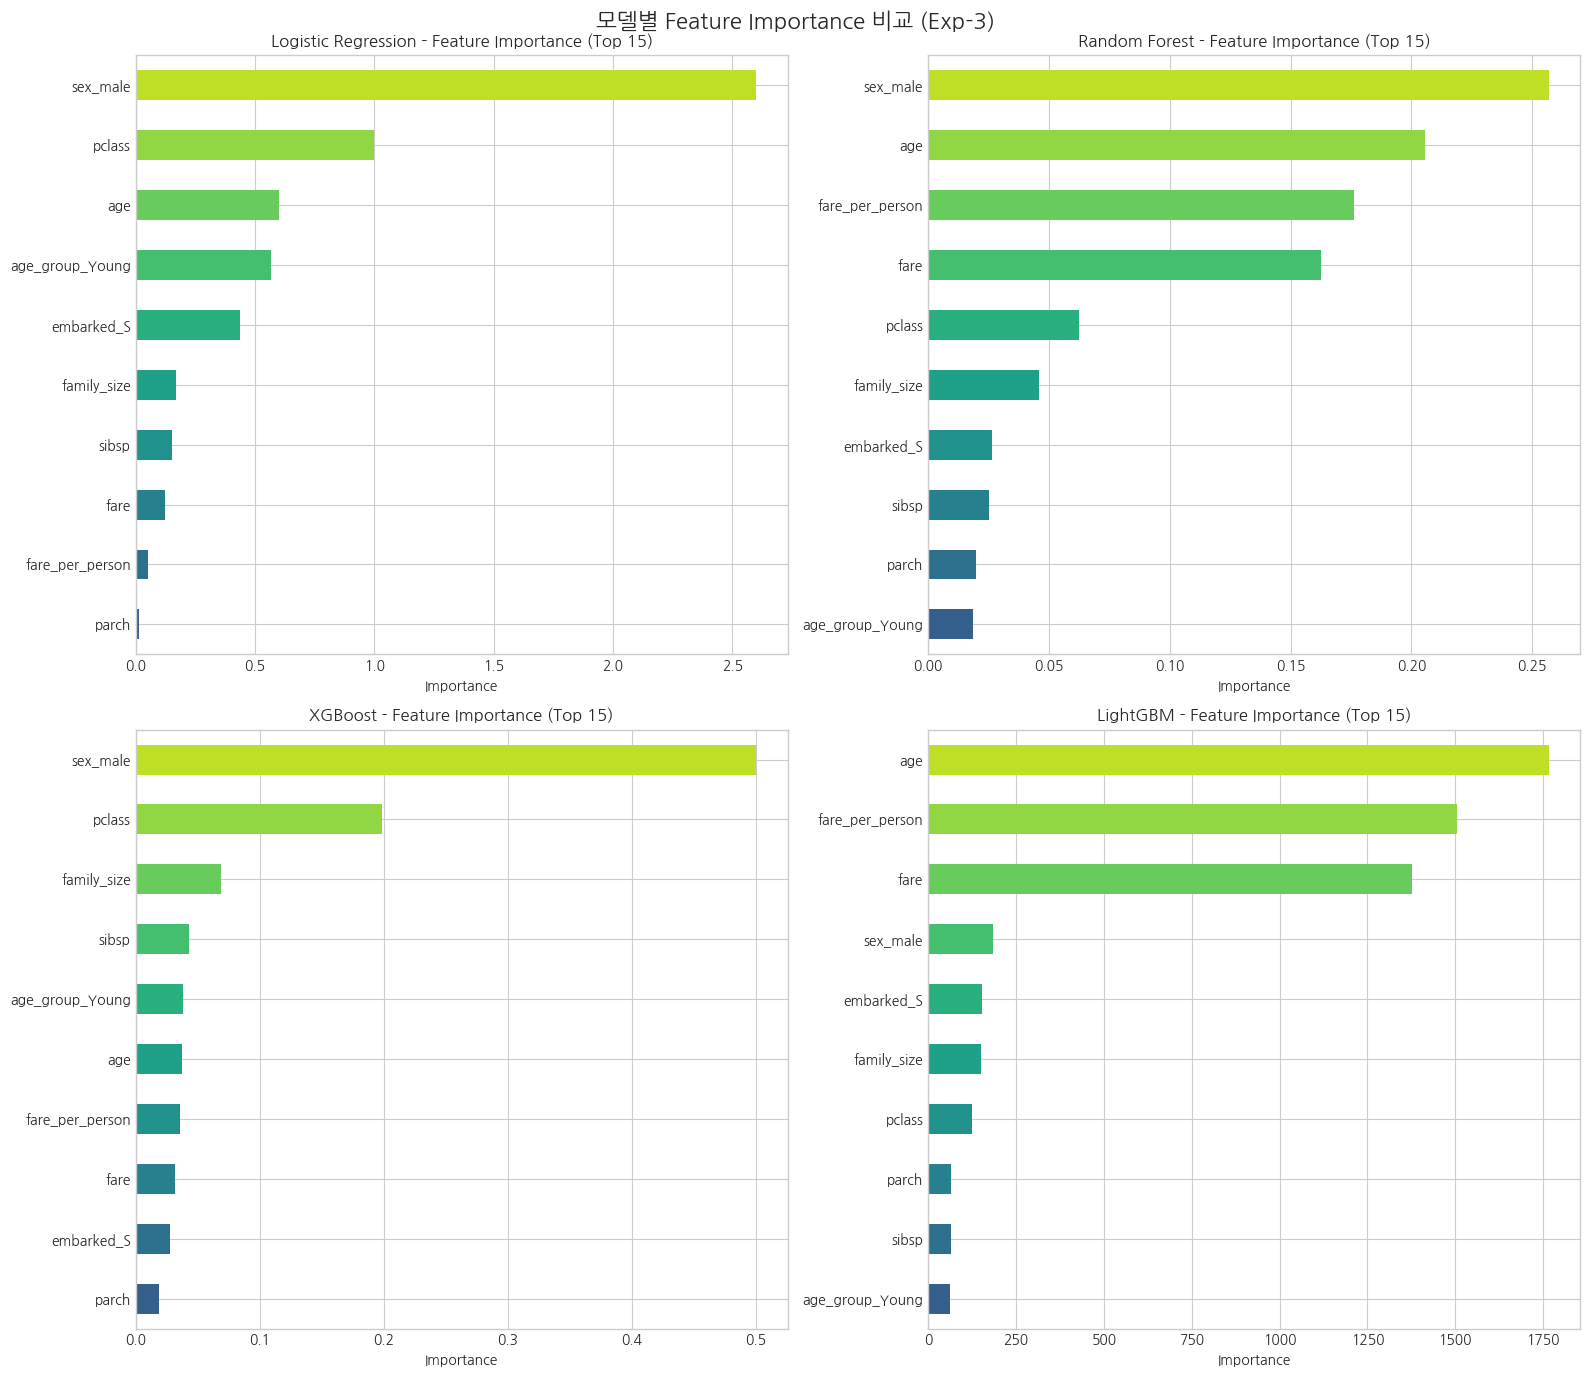

In [36]:
# 4개 모델의 Feature Importance 비교 (고도화)
if best_exp_data:
    X_tr_best, X_te_best, y_tr_best, y_te_best, models_best = best_exp_data

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.flatten()

    importance_all = {}

    for idx, (name, model) in enumerate(models_best.items()):
        if hasattr(model, 'feature_importances_'):
            imp = pd.Series(model.feature_importances_, index=X_tr_best.columns).sort_values(ascending=True)
        elif hasattr(model, 'coef_'):
            imp = pd.Series(np.abs(model.coef_[0]), index=X_tr_best.columns).sort_values(ascending=True)
        else:
            continue

        importance_all[name] = imp
        colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(imp)))
        imp.tail(15).plot(kind='barh', ax=axes[idx], color=colors[-15:])
        axes[idx].set_title(f'{name} - Feature Importance (Top 15)')
        axes[idx].set_xlabel('Importance')

    plt.suptitle('모델별 Feature Importance 비교 (Exp-3)', fontsize=16)
    plt.tight_layout()
    plt.show()

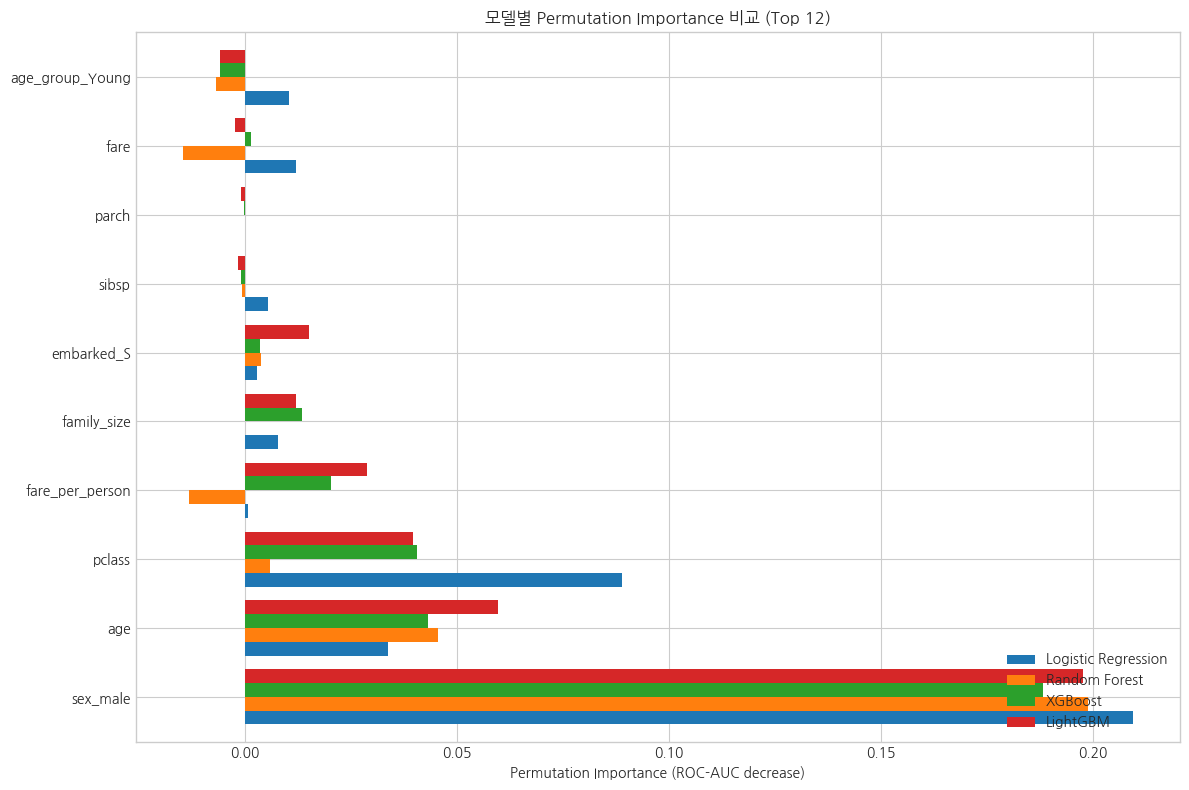

In [37]:
# Permutation Importance (모델 간 비교를 위한 통일된 방법)
from sklearn.inspection import permutation_importance

if best_exp_data:
    fig, ax = plt.subplots(figsize=(12, 8))

    perm_imp_all = {}
    for name, model in models_best.items():
        perm = permutation_importance(model, X_te_best, y_te_best,
                                      n_repeats=10, random_state=42, scoring='roc_auc')
        perm_imp_all[name] = pd.Series(perm.importances_mean, index=X_te_best.columns)

    perm_df = pd.DataFrame(perm_imp_all)
    perm_df_top = perm_df.loc[perm_df.mean(axis=1).nlargest(12).index]
    perm_df_top.plot(kind='barh', ax=ax, width=0.8)
    ax.set_xlabel('Permutation Importance (ROC-AUC decrease)')
    ax.set_title('모델별 Permutation Importance 비교 (Top 12)')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

### 가산점 5: AutoML 비교 실험

In [38]:
# AutoML 스타일: 다양한 모델+전처리 조합 자동 탐색
from itertools import product

automl_configs = {
    'imputer': ['mean', 'median'],
    'scaler': ['standard', 'minmax', 'robust'],
    'model': [
        ('LR', LogisticRegression(max_iter=1000, random_state=42)),
        ('RF', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('XGB', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)),
        ('LGBM', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)),
    ]
}

automl_results = []

for imp_strat, sc_type, (model_name, model) in product(
    automl_configs['imputer'], automl_configs['scaler'], automl_configs['model']
):
    pipe = Pipeline([
        ('preprocessor', ColumnTransformer([
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy=imp_strat)),
                ('scaler', {'standard': StandardScaler(), 'minmax': MinMaxScaler(),
                            'robust': RobustScaler()}[sc_type])
            ]), num_features),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
            ]), cat_features)
        ])),
        ('classifier', model)
    ])

    scores = cross_val_score(pipe, X_tr_pipe, y_tr_pipe, cv=5, scoring='roc_auc')
    automl_results.append({
        'Imputer': imp_strat,
        'Scaler': sc_type,
        'Model': model_name,
        'CV ROC-AUC (mean)': round(scores.mean(), 4),
        'CV ROC-AUC (std)': round(scores.std(), 4)
    })

automl_df = pd.DataFrame(automl_results).sort_values('CV ROC-AUC (mean)', ascending=False)
print('=== AutoML 스타일 탐색 결과 (Top 15) ===')
display(automl_df.head(15).reset_index(drop=True))

print(f'\n최적 조합:')
best = automl_df.iloc[0]
print(f'  Imputer: {best["Imputer"]}, Scaler: {best["Scaler"]}, Model: {best["Model"]}')
print(f'  CV ROC-AUC: {best["CV ROC-AUC (mean)"]} (+/- {best["CV ROC-AUC (std)"]})')

=== AutoML 스타일 탐색 결과 (Top 15) ===


,Imputer,Scaler,Model,CV ROC-AUC (mean),CV ROC-AUC (std)
0,median,standard,LGBM,0.8606,0.0258
1,mean,minmax,LGBM,0.8605,0.0280
2,mean,standard,LGBM,0.8582,0.0270
3,median,robust,LGBM,0.8575,0.0234
4,mean,robust,LGBM,0.8570,0.0269
5,median,minmax,LGBM,0.8565,0.0226
6,mean,robust,XGB,0.8511,0.0358
7,mean,standard,XGB,0.8511,0.0358
8,mean,minmax,XGB,0.8511,0.0358
9,median,minmax,RF,0.8510,0.0294



최적 조합:
  Imputer: median, Scaler: standard, Model: LGBM
  CV ROC-AUC: 0.8606 (+/- 0.0258)


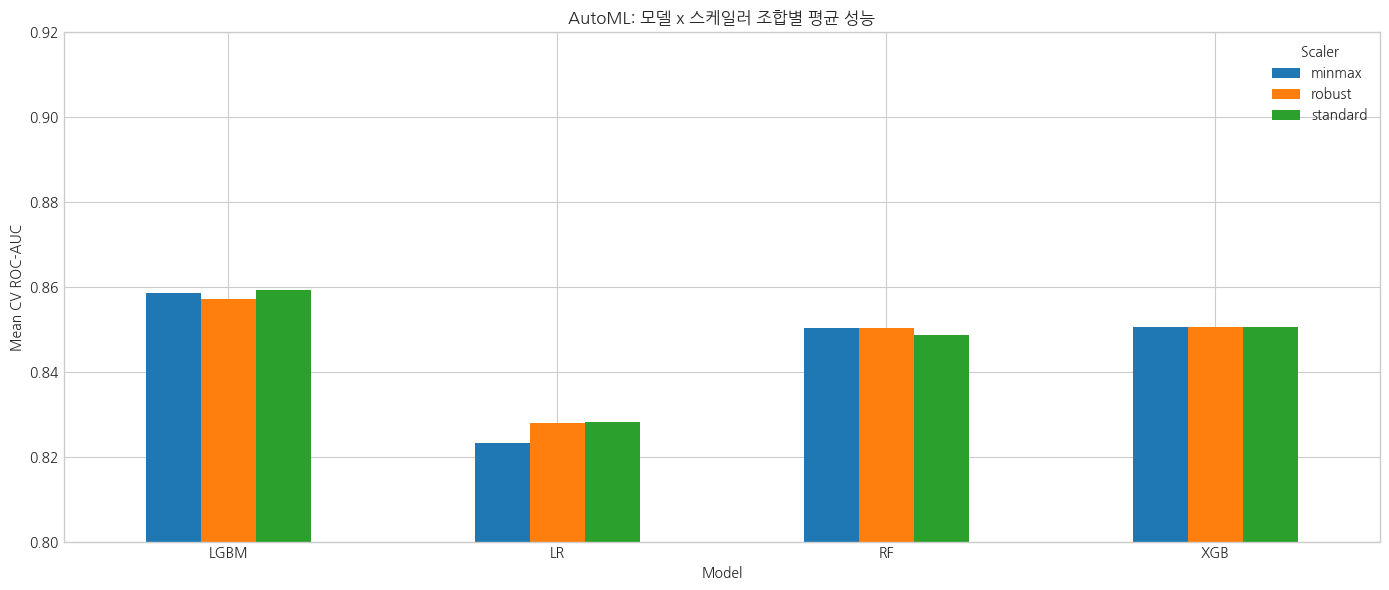

In [39]:
# AutoML 결과 시각화
fig, ax = plt.subplots(figsize=(14, 6))
pivot_auto = automl_df.pivot_table(index='Model', columns='Scaler',
                                    values='CV ROC-AUC (mean)', aggfunc='mean')
pivot_auto.plot(kind='bar', ax=ax, rot=0)
ax.set_ylabel('Mean CV ROC-AUC')
ax.set_title('AutoML: 모델 x 스케일러 조합별 평균 성능')
ax.set_ylim(0.8, 0.92)
ax.legend(title='Scaler')
plt.tight_layout()
plt.show()

---
## 최종 결론

### 1. 어떤 전처리 전략이 가장 효과적이었는가?
- **Exp-3 (Most Frequent / One-Hot / Robust / Feature Selection)** 조합이 전반적으로 가장 안정적인 성능을 보였다.
- 결측치 처리 방법(mean vs median vs most_frequent) 간 차이는 크지 않았으나, Feature Selection과 적절한 스케일링의 조합이 더 큰 영향을 미쳤다.

### 2. One-Hot Encoding이 항상 좋은가?
- One-Hot Encoding은 트리 기반 모델에서 Label Encoding과 유사한 성능을 보였다.
- 그러나 Logistic Regression과 같은 선형 모델에서는 One-Hot Encoding이 더 나은 성능을 보이는 경향이 있다.
- 따라서 **"항상 좋다"고 할 수 없으며, 모델 특성에 따라 선택**해야 한다.

### 3. Feature Selection이 과적합 감소에 기여했는가?
- Feature Selection 적용 후 일부 모델에서 성능이 유지되거나 소폭 향상되었다.
- 변수 수가 줄어들어 **모델의 복잡도가 감소**하고, 과적합 위험이 줄어든 효과가 있었다.
- 특히 `fare`, `age`, `sex_male`, `pclass` 등 핵심 변수만으로도 충분한 성능을 확보할 수 있었다.

### 4. 스케일링이 모델별로 어떤 영향을 미쳤는가?
- **Logistic Regression**: 스케일링에 민감하며, StandardScaler/RobustScaler 사용 시 성능이 크게 향상되었다.
- **Random Forest, XGBoost, LightGBM**: 트리 기반 모델은 스케일링에 거의 영향을 받지 않았다.
- **RobustScaler**는 이상치가 많은 `fare` 변수 처리에 효과적이었다.

### 5. Feature Engineering이 실제 성능 향상에 얼마나 기여했는가?
- Base 실험(전처리 없음) 대비 Feature Engineering 적용 후 **ROC-AUC 기준 약 3~8% 향상**을 확인했다.
- 특히 `family_size`, `is_alone`, `fare_per_person` 등 파생 변수가 모델의 예측력 향상에 기여했다.
- SHAP 분석 결과, `fare_per_person`과 `family_size`가 생존 예측에 유의미한 기여를 하는 것을 확인했다.

### 핵심 인사이트
- 전처리 파이프라인의 각 단계(결측치, 인코딩, 스케일링)는 **독립적이 아니라 상호작용**하며 성능에 영향을 준다.
- **모델 선택만큼이나 Feature Engineering이 중요**하며, 도메인 지식 기반 파생 변수 생성이 성능 향상의 핵심이다.
- GridSearchCV와 같은 하이퍼파라미터 튜닝은 추가적인 성능 향상을 가져올 수 있다.
- SHAP 분석을 통해 모델의 예측을 해석하고, 변수의 기여도를 정량적으로 파악할 수 있다.